In [1]:
from gsfit_rs.analytic_grad_shafranov.guazzotto_freidberg import Configuration, GuazzottoFreidberg
from gsfit_rs.imas import equilibrium_paths as ep
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# %matplotlib inline
# %matplotlib widget

In [4]:
"""Example 15 - Guazzotto-Freidberg analytic Grad-Shafranov equilibrium: high beta_p lower single null.

Builds the up-down asymmetric *lower single-null* tokamak of
Guazzotto & Freidberg, J. Plasma Phys. 87 (2021) 905870303 (Figure 9 / Table 3:
eps = 0.25, kappa = 1.8, delta = 0.6, kappa_X = 2.1, delta_X = 0.8, nu = 2.1; reference eigenvalue
alpha ~ 2.09 from Table 4), then fits the PF-coil currents on the (R, Z) grid
boundary that reproduce its vacuum field - a self-consistent, free-boundary test
case that GSFit can be asked to reconstruct.

The upper half of the boundary is a smooth Miller profile (kappa, delta), and the lower half has the X-point (kappa_X, delta_X).
Without up-down symmetry the flux expansion has 12 terms rather than 7 (GF Eq. 5.8).
nu = 2.1 is just below its maximum, nu_max = 1 / eps_hat = (1 + eps ** 2) / (2 * eps) = 2.125, above which the toroidal current density reverses at the inboard midplane (GF Eq. 2.10).
"""

import math

# --- Dimensionless shape / profile (GF Fig. 9, high beta_p single null) ---
eps = 0.25  # inverse aspect ratio a / r_geo
kappa = 1.8  # upper elongation
delta = 0.6  # upper triangularity
kappa_x = 2.1  # lower X-point elongation
delta_x = 0.8  # lower X-point triangularity
nu = 2.1  # profile parameter (~ poloidal beta)

# --- Dimensional inputs (illustrative; they set the scale, not the shape) ---
r_geo = 1.65  # geometric major radius [metre]
b_vacuum = 2.0  # vacuum toroidal field at r_geo [tesla]
# GF's Table 4 assumes q_0 = 1, which GF Eq. 6.12 gives for beta_0 = 0.0826: an on-axis pressure of 131.5 kPa.
# `p_axis` is the pressure where psi_hat = psi / psi_0 = 1, which is at (x, y) = (0, 0) rather than on the magnetic axis.
# psi_hat = 1.0125 on the magnetic axis, so p_axis = 131.5 kPa / 1.0125 ** 2.
p_axis = 1.283e5  # [pascal]

# --- (R, Z) grid; PF coils are placed on its boundary ---
# Memory in `get_coils` grows as (grid points) x (plasma cells), i.e. as d_grid_gf ** -4: this grid peaks at ~4 GiB
a_minor = eps * r_geo  # minor radius [metre]
z_upper_maximum = kappa * a_minor  # height of the upper maximum [metre]
# The analytic X-point, GF's (x, y) = (-x_X, -kappa_X), is at R = r_geo - a * delta_X (GF Eq. 4.3)
xpt_r = r_geo - a_minor * delta_x  # [metre]
xpt_z = -kappa_x * a_minor  # [metre]
gap_plasma_to_coils_r = 0.20  # [metre]
gap_plasma_to_coils_z = 0.25  # [metre]
# The grid is placed so that Z = 0 is a grid row, so the midplane profiles can be read straight off the grid, and so that the X-point is
# in the middle of a grid cell. The post-processor's boundary tracer looks for the separatrix crossing the edges of the cell holding the
# analytic X-point. The fitted total flux (plasma + coils) puts its X-point a little away from the analytic one, so an X-point near a cell
# edge can leave the separatrix missing that cell's edges, and the tracer then fails.
# Z: the X-point is half way between rows, xpt_z = -(n_z_below_xpt + 1/2) * d_grid_gf, for a grid spacing close to 12 mm
n_z_below_xpt = round(-xpt_z / 0.012 - 0.5)
d_grid_gf = -xpt_z / (n_z_below_xpt + 0.5)  # grid spacing in both R and Z [metre]
n_z_below_midplane = n_z_below_xpt + 1 + math.ceil(gap_plasma_to_coils_z / d_grid_gf)
n_z_above_midplane = math.ceil((z_upper_maximum + gap_plasma_to_coils_z) / d_grid_gf)
n_z = n_z_below_midplane + n_z_above_midplane + 1
z_min = -n_z_below_midplane * d_grid_gf  # [metre]
z_max = n_z_above_midplane * d_grid_gf  # [metre]
# R: the X-point is half way between columns
n_r_inboard_of_xpt = math.ceil((xpt_r - (r_geo - a_minor - gap_plasma_to_coils_r)) / d_grid_gf - 0.5)
r_min = xpt_r - (n_r_inboard_of_xpt + 0.5) * d_grid_gf  # [metre]
n_r = math.ceil((r_geo + a_minor + gap_plasma_to_coils_r - r_min) / d_grid_gf) + 1
r_max = r_min + (n_r - 1) * d_grid_gf  # [metre]

# --- Numerical control ---
n_radial_expansion = 150  # C_n / S_n series length

# 1. Boundary topology + its shape (lower single null: smooth upper half, X-point lower half)
configuration = Configuration.SingleNull(kappa=kappa, delta=delta, kappa_x=kappa_x, delta_x=delta_x)

# 2. Construct the analytic equilibrium
gf = GuazzottoFreidberg(
    configuration,
    eps=eps,
    nu=nu,
    r_geo=r_geo,
    bt_vac_at_r_geo=b_vacuum,
    p_axis=p_axis,
    n_r=n_r,
    n_z=n_z,
    r_min=r_min,
    r_max=r_max,
    z_min=z_min,
    z_max=z_max,
    n_radial_expansion=n_radial_expansion,
)
print(f"GF high beta_p lower single null: eps={eps}, kappa={kappa}, delta={delta}, kappa_x={kappa_x}, delta_x={delta_x}, nu={nu}")
print(f"grid: R in [{r_min:.4f}, {r_max:.4f}] m, Z in [{z_min:.4f}, {z_max:.4f}] m, {n_r}x{n_z}, d_r = d_z = {d_grid_gf * 1.0e3:.3f} mm")
print(f"analytic X-point: R = {xpt_r:.4f} m, Z = {xpt_z:.4f} m")

# 3. Solve the eigenvalue alpha and the normalised flux psi(R, Z)
gf.solve()

GF high beta_p lower single null: eps=0.25, kappa=1.8, delta=0.6, kappa_x=2.1, delta_x=0.8, nu=2.1
grid: R in [1.0273, 2.2699] m, Z in [-1.1231, 1.0037] m, 105x179, d_r = d_z = 11.948 mm
analytic X-point: R = 1.3200 m, Z = -0.8662 m


alpha = 2.089743 (GF Table 4: 2.09);  beta_0 = 0.0806;  bt_diamagnetic_shift = -44.865 mT;  psi_0 = 0.8019 Wb
psi_hat on the magnetic axis = 1.0122 (the grid maximum)


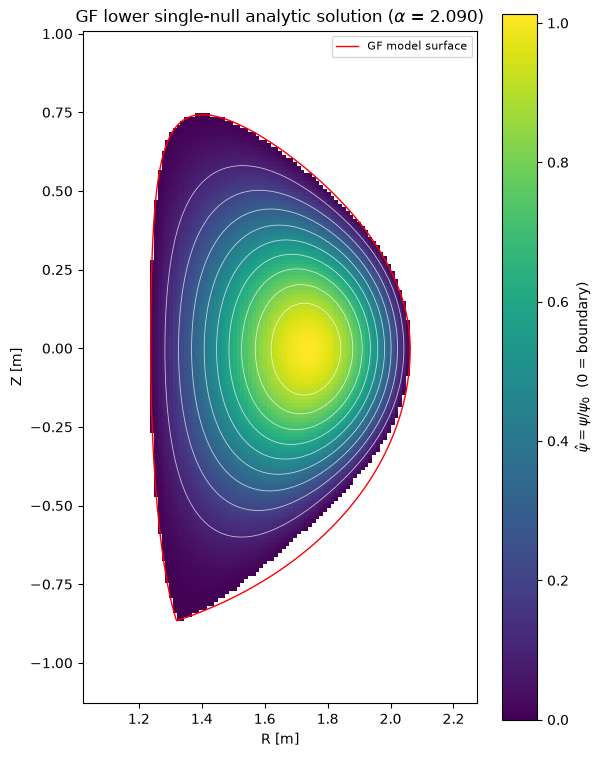

In [5]:
# --- The analytic solution on the (R, Z) grid, with GF's model surface ---
# The equilibrium IDS is only filled once the PF coils are fitted (next cell); until then the
# analytic flux and the plasma mask are what `solve()` provides.
r = np.linspace(gf.r_min, gf.r_max, gf.n_r)
z = np.linspace(gf.z_min, gf.z_max, gf.n_z)
mask = gf.mask  # 1 inside the analytic plasma, 0 elsewhere
# GF's normalised flux: 1 at (x, y) = (0, 0) and 0 on the boundary. NaN outside the plasma, where the
# truncated series is unphysical
psi_hat = np.where(mask > 0, gf.psi_analytic / gf.psi_0, np.nan)
# The model surface: the analytic boundary matches its position, slope and curvature at the inner and outer midplanes,
# the upper maximum and the lower X-point. Elsewhere the analytic boundary is close to it, but not on it.
model_surface_r, model_surface_z = gf.model_surface(n_point_per_half=200)
print(f"alpha = {gf.alpha:.6f} (GF Table 4: 2.09);  beta_0 = {gf.beta_0:.4f};  bt_diamagnetic_shift = {gf.bt_diamagnetic_shift * 1e3:.3f} mT;  psi_0 = {gf.psi_0:.4f} Wb")
print(f"psi_hat on the magnetic axis = {np.nanmax(psi_hat):.4f} (the grid maximum)")

fig, ax = plt.subplots(figsize=(6, 8))
# A pixel plot rather than a filled contour: `contourf` leaves a jagged edge where the plasma meets the NaN outside it.
# `shading="nearest"` centres each pixel on its grid point.
fill = ax.pcolormesh(r, z, psi_hat, vmin=0.0, vmax=np.nanmax(psi_hat), cmap="viridis", shading="nearest")
fig.colorbar(fill, ax=ax, label="$\\hat{\\psi} = \\psi / \\psi_0$  (0 = boundary)")
ax.contour(r, z, psi_hat, levels=np.linspace(0.1, 0.9, 9), colors="white", linewidths=0.6, alpha=0.7)
ax.plot(model_surface_r, model_surface_z, color="red", lw=1.0, label="GF model surface")
ax.set_aspect("equal")
ax.set_xlabel("R [m]")
ax.set_ylabel("Z [m]")
ax.set_title(f"GF lower single-null analytic solution ($\\alpha$ = {gf.alpha:.3f})")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

equilibrium_post_processor: starting
PF coils (unknowns)                     : 564
plasma grid points constraining the fit : 6588
least squares: 6588 constraints vs 564 unknowns -> OVER-determined
chi^2 of the vacuum flux fit            : 1.442e-09
max fit error / (psi_axis - psi_boundary): 1.534e-04


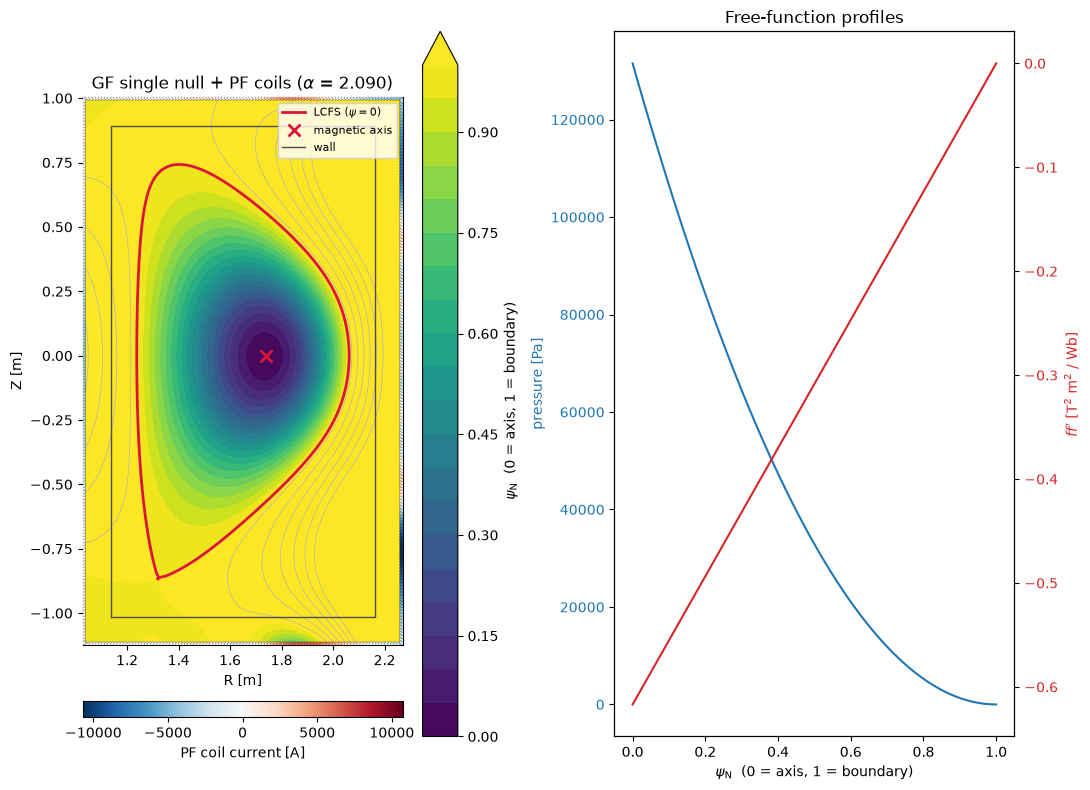

In [6]:
# --- Fit PF coils to reproduce the equilibrium, print the fit determinacy, then plot the free-boundary equilibrium ---
from gsfit_rs import Wall

# Whole-domain control: constrain the total flux at every analytic plasma grid point,
# so the grid points inside the plasma are the least-squares constraints.
mesh_r, mesh_z = np.meshgrid(r, z)  # (n_z, n_r)
control_points = np.column_stack([mesh_r[mask > 0], mesh_z[mask > 0]])

# Wall: a rectangle enclosing the plasma, with extra room below the X-point for the divertor legs. The post-processor traces the
# scrape-off layer legs up to it, and GSFit's reconstruction below uses it as the limiter and vacuum vessel.
# It sits 0.10 m inside the PF coils on every side. `unit(0)` is the vacuum vessel contour; it is the only limiter unit, so it
# also supplies every candidate limit point.
lim_r_lo = r_geo - a_minor - 0.10  # [metre]
lim_r_hi = r_geo + a_minor + 0.10  # [metre]
lim_z_lo = xpt_z - 0.15  # [metre]
lim_z_hi = z_upper_maximum + 0.15  # [metre]
n_side = 60
edge_r = np.linspace(lim_r_lo, lim_r_hi, n_side)
edge_z = np.linspace(lim_z_lo, lim_z_hi, n_side)
limiter_r = np.concatenate([edge_r, np.full(n_side, lim_r_hi), edge_r[::-1], np.full(n_side, lim_r_lo)])
limiter_z = np.concatenate([np.full(n_side, lim_z_lo), edge_z, np.full(n_side, lim_z_hi), edge_z[::-1]])
wall = Wall()
wall.add_limiter_unit(name="vacuum_vessel", r=limiter_r, z=limiter_z)

# Fits the coils, stores the free-boundary equilibrium (plasma + coils) in the IDS, and post-processes it.
# The regularisation is weaker than example 14's 1.0e-6: relative to the plasma size these coils are about twice as far away, so the
# shaping field needs larger coil currents, and 1.0e-6 damps them enough to leave a rippled fit error of about 3e-4 * psi_axis at the
# boundary. At 1.0e-8 what is left is the O(d_grid_gf ** 2) error of representing the plasma current by one filament per grid cell.
gf_coils = gf.get_coils(coil_regularisation_weight=1.0e-8, control_points=control_points, wall=wall)

# --- Read the free-boundary equilibrium back out of the IDS ---
# The flux is the total (plasma + coils), so it is valid in the vacuum as well. The magnetic axis, the
# boundary flux (0) and the X-point are the analytic ones.
gf_equilibrium_ids = gf.equilibrium_ids
psi_total = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi)
psi_axis = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.psi_magnetic_axis)
psi_boundary = gf_equilibrium_ids.get(ep.time_slice[0].boundary.psi)
# Not masked, unlike `profiles_2d/psi_norm`, so it carries on past 1 into the vacuum
psi_norm_total = (psi_total - psi_axis) / (psi_boundary - psi_axis)
boundary_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
boundary_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)
mag_r = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.r)
mag_z = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.z)

# One single-filament coil per GF boundary node
gf_coil_names = gf_coils.keys(["pf"])
coil_r = np.array([gf_coils.get_array1(["pf", coil_name, "geometry", "r"])[0] for coil_name in gf_coil_names])
coil_z = np.array([gf_coils.get_array1(["pf", coil_name, "geometry", "z"])[0] for coil_name in gf_coil_names])
coil_current = np.array([gf_coils.get_array1(["pf", coil_name, "i", "experimental", "value"])[0] for coil_name in gf_coil_names])

# --- Determinacy of the least-squares fit (constraints vs unknowns) ---
n_coil = coil_current.size
n_constraint = control_points.shape[0]
status = "OVER-determined" if n_constraint >= n_coil else "UNDER-determined"
print(f"PF coils (unknowns)                     : {n_coil}")
print(f"plasma grid points constraining the fit : {n_constraint}")
print(f"least squares: {n_constraint} constraints vs {n_coil} unknowns -> {status}")

# --- Quality of the fit: chi^2 of the vacuum flux at the plasma grid points (the control points) ---
# The coils are fitted so that their flux matches the GF vacuum flux, psi_vac^GF = psi^GF - psi_plasma, where psi^GF is the
# analytic flux and psi_plasma is the flux of the GF plasma current. The coil flux is psi_vac^PF.
# chi^2 = 1 / N_plas * sum_k [(psi_vac^GF(R_k, Z_k) - psi_vac^PF(R_k, Z_k)) / (psi_GF,axis - psi_GF,boundary)] ** 2
psi_coils = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi_coils)  # [weber]
psi_plasma = psi_total - psi_coils  # [weber]
psi_vacuum_gf = gf.psi_analytic[mask > 0] - psi_plasma[mask > 0]  # [weber]
psi_vacuum_pf = psi_coils[mask > 0]  # [weber]
chi_sq = np.mean(((psi_vacuum_gf - psi_vacuum_pf) / (psi_axis - psi_boundary)) ** 2)  # [dimensionless]
print(f"chi^2 of the vacuum flux fit            : {chi_sq:.3e}")
fit_error_max = np.max(np.abs(psi_vacuum_gf - psi_vacuum_pf)) / (psi_axis - psi_boundary)  # [dimensionless]
print(f"max fit error / (psi_axis - psi_boundary): {fit_error_max:.3e}")

fig, (ax_flux, ax_profile) = plt.subplots(1, 2, figsize=(11, 8))

# --- Panel 1: total flux surfaces + fitted PF coils ---
fill = ax_flux.contourf(r, z, psi_norm_total, levels=np.linspace(0.0, 1.0, 21), cmap="viridis", extend="max")
fig.colorbar(fill, ax=ax_flux, label="$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
# A few vacuum flux surfaces (psi_N > 1) show the coil-shaped field outside the plasma.
ax_flux.contour(r, z, psi_norm_total, levels=np.linspace(1.05, 1.6, 6), colors="0.7", linewidths=0.5)
ax_flux.plot(boundary_r, boundary_z, color="crimson", lw=2.0, label="LCFS ($\\psi = 0$)")
ax_flux.plot(mag_r, mag_z, "x", color="crimson", ms=9, mew=2, label="magnetic axis")
current_abs_max = np.abs(coil_current).max()
scatter = ax_flux.scatter(
    coil_r,
    coil_z,
    c=coil_current,
    cmap="RdBu_r",
    vmin=-current_abs_max,
    vmax=current_abs_max,
    s=18,
    edgecolors="k",
    linewidths=0.2,
    zorder=5,
)
fig.colorbar(scatter, ax=ax_flux, location="bottom", label="PF coil current [A]", pad=0.08, fraction=0.05)
ax_flux.plot(limiter_r, limiter_z, color="0.3", lw=1.0, label="wall")
ax_flux.set_aspect("equal")
ax_flux.set_xlabel("R [m]")
ax_flux.set_ylabel("Z [m]")
ax_flux.set_title(f"GF single null + PF coils ($\\alpha$ = {gf.alpha:.3f})")
ax_flux.legend(loc="upper right", fontsize=8)

# --- Panel 2: pressure and ff' vs psi_N ---
profile_psi_n = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)
profile_pressure = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.pressure)
profile_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)
ax_profile.plot(profile_psi_n, profile_pressure, color="tab:blue")
ax_profile.set_xlabel("$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
ax_profile.set_ylabel("pressure [Pa]", color="tab:blue")
ax_profile.tick_params(axis="y", labelcolor="tab:blue")
ax_ff_prime = ax_profile.twinx()
ax_ff_prime.plot(profile_psi_n, profile_ff_prime, color="tab:red")
ax_ff_prime.set_ylabel("$ff'$ [T$^2$ m$^2$ / Wb]", color="tab:red")
ax_ff_prime.tick_params(axis="y", labelcolor="tab:red")
ax_profile.set_title("Free-function profiles")

fig.tight_layout()
plt.show()

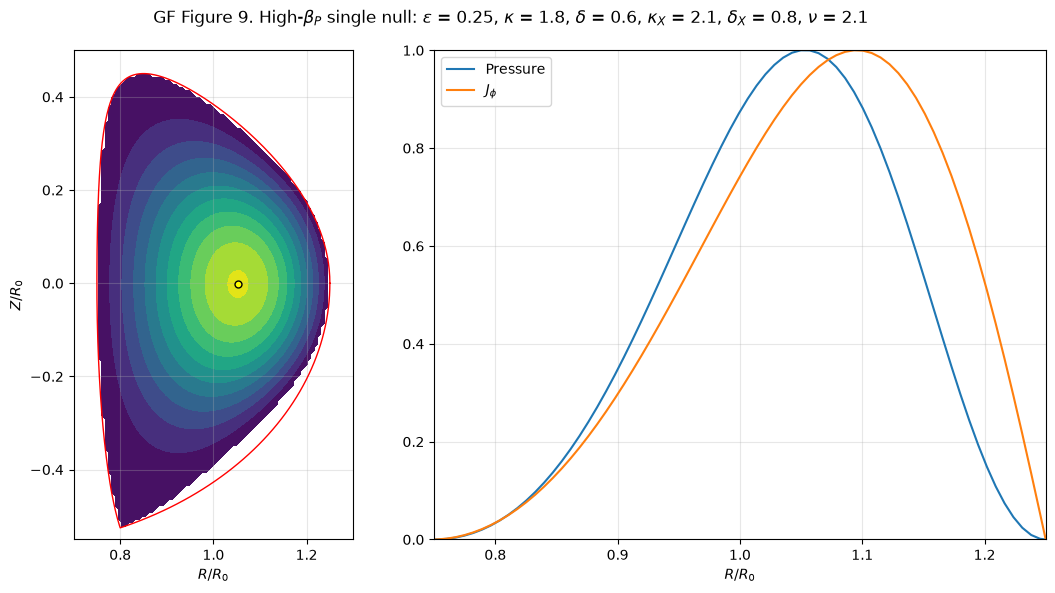

                 this notebook   GF Table 4
alpha                   2.0897         2.09
beta_T                  0.0177        0.018
beta_P                  2.1578         2.16
l_i                     1.0041         1.00
q_95                    6.1948         6.17  (post-processor)
q_*                     3.9440         3.71  (kappa_95 = 1.6447, from the post-processor)
q_0                     1.0005         1.00  (post-processor; GF assume q_0 = 1, which set p_axis)


In [7]:
# --- Reproduce GF Figure 9, and compare with GF Table 4 ---
# Left: the flux surfaces and GF's model surface (red), in R / r_geo and Z / r_geo like GF's figure.
# Right: the pressure and the toroidal current density along the midplane, Z = 0, each normalised to its maximum.
# Both are read from the post-processed equilibrium IDS: the pressure profile is mapped onto the midplane through psi_N.
# The boundary crosses the midplane at GF's matching points (x, y) = (-1, 0) and (1, 0), R = r_geo * (1 -/+ eps), where both vanish.
i_z_midplane = int(np.argmin(np.abs(z)))
assert abs(z[i_z_midplane]) < 1.0e-9, "Z = 0 must be a grid row"
psi_norm_2d = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi_norm)  # masked: 0 outside the plasma
j_phi_2d = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].j_phi)  # [ampere / metre ** 2]
midplane_in_plasma = mask[i_z_midplane, :] > 0
midplane_r = np.concatenate([[r_geo * (1.0 - eps)], r[midplane_in_plasma], [r_geo * (1.0 + eps)]])  # [metre]
midplane_pressure = np.concatenate([[0.0], np.interp(psi_norm_2d[i_z_midplane, midplane_in_plasma], profile_psi_n, profile_pressure), [0.0]])  # [pascal]
midplane_j_phi = np.concatenate([[0.0], j_phi_2d[i_z_midplane, midplane_in_plasma], [0.0]])  # [ampere / metre ** 2]

fig, (ax_surfaces, ax_midplane) = plt.subplots(1, 2, figsize=(11, 6), gridspec_kw={"width_ratios": [1.0, 1.6]})
ax_surfaces.contourf(r / r_geo, z / r_geo, psi_hat, levels=10, cmap="viridis")
ax_surfaces.plot(model_surface_r / r_geo, model_surface_z / r_geo, color="red", lw=1.0)
ax_surfaces.plot(mag_r / r_geo, mag_z / r_geo, "o", color="yellow", mec="k", ms=5)
ax_surfaces.set_aspect("equal")
ax_surfaces.set_xlim(0.7, 1.3)
ax_surfaces.set_ylim(-0.55, 0.5)
ax_surfaces.set_xlabel("$R / R_0$")
ax_surfaces.set_ylabel("$Z / R_0$")
ax_surfaces.grid(alpha=0.3)

ax_midplane.plot(midplane_r / r_geo, midplane_pressure / midplane_pressure.max(), label="Pressure")
ax_midplane.plot(midplane_r / r_geo, midplane_j_phi / midplane_j_phi.max(), label="$J_\\phi$")
ax_midplane.set_xlim(1.0 - eps, 1.0 + eps)
ax_midplane.set_ylim(0.0, 1.0)
ax_midplane.set_xlabel("$R / R_0$")
ax_midplane.grid(alpha=0.3)
ax_midplane.legend(loc="upper left")
fig.suptitle(f"GF Figure 9. High-$\\beta_P$ single null: $\\epsilon$ = {eps}, $\\kappa$ = {kappa}, $\\delta$ = {delta}, $\\kappa_X$ = {kappa_x}, $\\delta_X$ = {delta_x}, $\\nu$ = {nu}")
fig.tight_layout()
plt.show()

# --- GF Table 4, "Single null, small eps, high beta_P" ---
# GF's integrals (Eqs. 6.6 - 6.10) are over the plasma in the normalised coordinates, where dx dy = R dR dZ / (eps * r_geo ** 2 * a).
# They are summed over the grid cells inside the plasma, so they carry a small discretisation error.
# Each is independent of how psi is normalised, so psi_hat, which is 1 at (x, y) = (0, 0) rather than on the magnetic axis, is used directly.
eps_hat = 2.0 * eps / (1.0 + eps**2)  # [dimensionless]
d_r = r[1] - r[0]  # [metre]
d_z = z[1] - z[0]  # [metre]
plasma = mask > 0
plasma_r = mesh_r[plasma]  # [metre]
plasma_x = (plasma_r**2 / r_geo**2 - 1.0 - eps**2) / (2.0 * eps)  # [dimensionless]
plasma_psi_hat = gf.psi_analytic[plasma] / gf.psi_0  # [dimensionless]
plasma_d_x_d_y = plasma_r * d_r * d_z / (eps * r_geo**2 * a_minor)  # [dimensionless]
current_weight = (1.0 + nu * eps_hat * plasma_x) / (1.0 + eps_hat * plasma_x)  # [dimensionless]
integral_area = np.sum(plasma_d_x_d_y)
integral_psi_squared = np.sum(plasma_psi_hat**2 * plasma_d_x_d_y)
integral_current = np.sum(current_weight * plasma_psi_hat * plasma_d_x_d_y)
integral_current_psi = np.sum(current_weight * plasma_psi_hat**2 * plasma_d_x_d_y)

beta_t = gf.beta_0 * integral_psi_squared / integral_area  # GF Eq. 6.6
beta_p = nu * integral_psi_squared / integral_current_psi  # GF Eq. 6.7
l_i = 4.0 * np.pi / gf.alpha**2 * integral_current_psi / integral_current**2  # GF Eq. 6.9
# GF Eq. 6.10, with the elongation of the 95% flux surface for a divertor. GF do not say how they measure that elongation, and q_* is
# sensitive to it through 1 + kappa_95 ** 2. The post-processor's elongation is the (R, Z) height over width of the psi_N = 0.95 surface,
# which gives q_* = 3.94 against GF's 3.71: GF's value needs kappa_95 = 1.58, the post-processor's elongation at psi_N ~ 0.92
profile_elongation = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.elongation)
kappa_95 = np.interp(0.95, profile_psi_n, profile_elongation)
q_star = np.pi * eps / gf.alpha * np.sqrt(nu / gf.beta_0) * (1.0 + kappa_95**2) / integral_current
# The safety factors from the post-processor. GF quote q_95 = q(psi = 0.05), with their psi 1 on the axis and 0 on the boundary, which is psi_N = 0.95
q_axis = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.q_axis)
q_95 = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.q_95)

print("                 this notebook   GF Table 4")
print(f"alpha            {gf.alpha:13.4f}   {2.09:10.2f}")
print(f"beta_T           {beta_t:13.4f}   {0.018:10.3f}")
print(f"beta_P           {beta_p:13.4f}   {2.16:10.2f}")
print(f"l_i              {l_i:13.4f}   {1.00:10.2f}")
print(f"q_95             {q_95:13.4f}   {6.17:10.2f}  (post-processor)")
print(f"q_*              {q_star:13.4f}   {3.71:10.2f}  (kappa_95 = {kappa_95:.4f}, from the post-processor)")
print(f"q_0              {q_axis:13.4f}   {1.0:10.2f}  (post-processor; GF assume q_0 = 1, which set p_axis)")

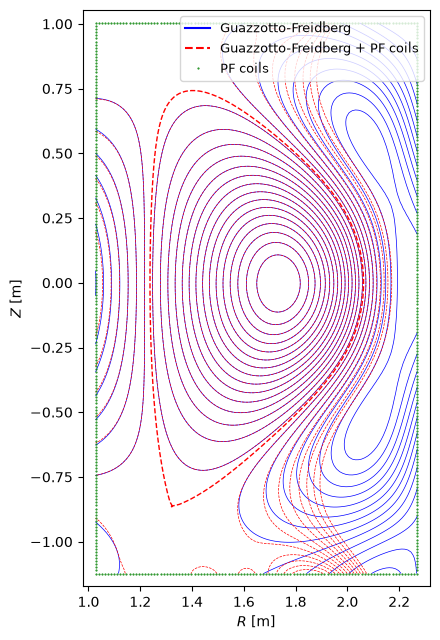

In [8]:
# --- Compare the analytic solution with the analytic + PF-coil (free-boundary) solution ---
# Same contour levels for both; expect agreement inside the plasma, disagreement outside.
from matplotlib.lines import Line2D

# Unmasked analytic flux on the whole grid: the truncated series is invalid - and diverges far
# outside - but it is kept unmasked so it can be plotted anyway for comparison.
psi_analytic = gf.psi_analytic

psi_mag_axis = gf.equilibrium_ids.get(ep.time_slice[0].global_quantities.psi_magnetic_axis)

# Levels from the plasma's own flux range, so the far-field divergence of the series cannot blow up the contour range.
# matplotlib draws no lines where the series has run off to +/-1e15, leaving a clean comparison.
levels = np.linspace(-0.5 * psi_mag_axis, psi_mag_axis, 24)

fig, ax = plt.subplots(figsize=(5, 6.5))

# Analytic solution: solid blue
ax.contour(r, z, psi_analytic, levels=levels, colors="blue", linestyles="solid", linewidths=0.5)
# Analytic + PF coils: dashed red, at the SAME levels
ax.contour(r, z, psi_total, levels=levels, colors="red", linestyles="dashed", linewidths=0.5)

# Plasma boundary drawn thicker, from the post-processor's marching-squares tracer on the total flux
# (sub-grid resolution, unlike a grid contour).
ax.plot(boundary_r, boundary_z, color="red", linestyle="--", linewidth=1.0)

ax.plot(
    coil_r,
    coil_z,
    color="green",
    linestyle="none",
    marker="o",
    markersize=0.5,
)

ax.legend(
    handles=[
        Line2D([0], [0], color="blue", linestyle="-", label="Guazzotto-Freidberg"),
        Line2D([0], [0], color="red", linestyle="--", label="Guazzotto-Freidberg + PF coils"),
        Line2D([0], [0], color="green", linestyle="none", marker="o", markersize=0.5, label="PF coils"),
    ],
    loc="upper right",
    fontsize=9,
)
ax.set_aspect("equal")
ax.set_xlabel("$R$ [m]")
ax.set_ylabel("$Z$ [m]")
ax.set_xlim(gf.r_min - 0.05, gf.r_max + 0.05)
ax.set_ylim(gf.z_min - 0.05, gf.z_max + 0.05)
fig.tight_layout()
plt.show()

Synthetic sensors on the GF equilibrium: 40 flux loops, 42 poloidal BP probes


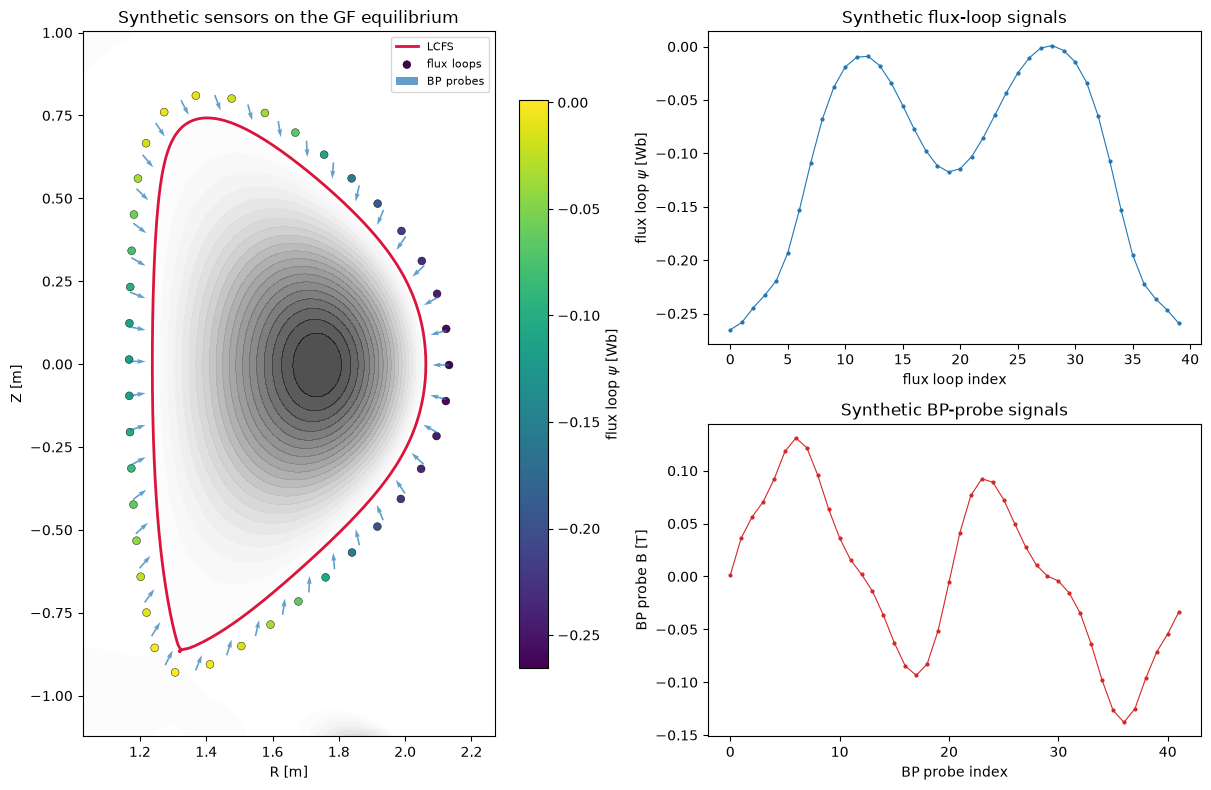

In [9]:
# --- Synthetic magnetic diagnostics from the GF equilibrium ---
# Build a custom sensor set 7 cm outside the plasma: 40 flux loops and 42 BP probes, each set equally spaced by arc length around an outward-offset copy of the free-boundary LCFS.
# Each set starts with a sensor on the low field side midplane. Unlike example 14's double null, a single null is not up/down symmetric, so neither are the sensor sets.
# The BP probes are oriented to point at the magnetic axis. Requires get_coils() above.
import numpy.typing as npt
from gsfit_rs import BpProbes, FluxLoops

sensor_standoff = 0.07  # perpendicular gap between the plasma boundary and the sensors [metre]
n_flux_loop = 40
n_bp_probe = 42

# --- Free-boundary LCFS + magnetic axis from the equilibrium IDS ---
lcfs_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
lcfs_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)
mag_r = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.r)
mag_z = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.z)


def sensor_ring(
    boundary_r: npt.NDArray[np.float64],
    boundary_z: npt.NDArray[np.float64],
    axis_r: float,
    axis_z: float,
    standoff: float,
    n_sensor: int,
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """
    Place sensors, equally spaced by arc length, on a curve `standoff` outside a closed boundary.

    The curve is the boundary offset along its outward normal (away from the magnetic axis).
    The first sensor is where the curve crosses the midplane, Z = axis_z, on the low field side, and the others follow anticlockwise in (R, Z).

    :param boundary_r: Closed boundary radial positions [metre]
    :param boundary_z: Closed boundary vertical positions [metre]
    :param axis_r: Magnetic axis radial position [metre]
    :param axis_z: Magnetic axis vertical position, which defines the midplane [metre]
    :param standoff: Perpendicular gap between the boundary and the sensors [metre]
    :param n_sensor: Number of sensors
    :return: Sensor radial positions [metre] and vertical positions [metre], each shape (n_sensor,)
    """
    boundary_r = np.asarray(boundary_r, dtype=float)
    boundary_z = np.asarray(boundary_z, dtype=float)
    # Drop a duplicate closing vertex so the loop is not double-counted.
    if np.hypot(boundary_r[0] - boundary_r[-1], boundary_z[0] - boundary_z[-1]) < 1.0e-9:
        boundary_r = boundary_r[:-1]
        boundary_z = boundary_z[:-1]

    # Outward normal at each vertex: rotate the wrapped central-difference tangent by 90 degrees,
    # then flip it to point away from the magnetic axis.
    tangent_r = np.roll(boundary_r, -1) - np.roll(boundary_r, 1)
    tangent_z = np.roll(boundary_z, -1) - np.roll(boundary_z, 1)
    normal_r = tangent_z
    normal_z = -tangent_r
    normal_length = np.maximum(np.hypot(normal_r, normal_z), 1.0e-12)
    normal_r /= normal_length
    normal_z /= normal_length
    pointing_inward = (boundary_r - axis_r) * normal_r + (boundary_z - axis_z) * normal_z < 0.0
    normal_r[pointing_inward] *= -1.0
    normal_z[pointing_inward] *= -1.0

    offset_r = boundary_r + standoff * normal_r
    offset_z = boundary_z + standoff * normal_z

    # Orient the offset curve anticlockwise in (R, Z), from the sign of its shoelace area, so it rises through the low field side midplane
    signed_area = 0.5 * np.sum(offset_r * np.roll(offset_z, -1) - np.roll(offset_r, -1) * offset_z)  # [metre^2]
    if signed_area < 0.0:
        offset_r = offset_r[::-1]
        offset_z = offset_z[::-1]

    # Find the segment on which the curve crosses the midplane upwards, on the low field side.
    # A vertex exactly on the midplane belongs to only one crossing segment, as the comparisons are strict on one side.
    n_vertex = offset_r.size
    i_vertex_low_field_side_list = []
    for i_vertex in range(n_vertex):
        i_vertex_next = (i_vertex + 1) % n_vertex
        if offset_z[i_vertex] < axis_z <= offset_z[i_vertex_next] and offset_r[i_vertex] > axis_r:
            i_vertex_low_field_side_list.append(i_vertex)
    if len(i_vertex_low_field_side_list) != 1:
        raise ValueError(f"the offset curve must cross the low field side midplane once; found {len(i_vertex_low_field_side_list)} crossings")
    i_vertex_low_field_side = i_vertex_low_field_side_list[0]

    # The curve, reordered to run once around from the low field side midplane crossing back to it
    i_vertex_next = (i_vertex_low_field_side + 1) % n_vertex
    fraction = (axis_z - offset_z[i_vertex_low_field_side]) / (offset_z[i_vertex_next] - offset_z[i_vertex_low_field_side])  # [dimensionless]
    crossing_r = offset_r[i_vertex_low_field_side] + fraction * (offset_r[i_vertex_next] - offset_r[i_vertex_low_field_side])  # [metre]
    loop_r = np.full(n_vertex + 2, np.nan)  # [metre]
    loop_z = np.full(n_vertex + 2, np.nan)  # [metre]
    loop_r[0] = crossing_r
    loop_z[0] = axis_z
    for i_loop_vertex in range(n_vertex):
        i_vertex = (i_vertex_low_field_side + 1 + i_loop_vertex) % n_vertex
        loop_r[i_loop_vertex + 1] = offset_r[i_vertex]
        loop_z[i_loop_vertex + 1] = offset_z[i_vertex]
    loop_r[-1] = crossing_r
    loop_z[-1] = axis_z

    # Sample at equal arc length; the end of the loop is its start, so it is not sampled twice
    arc_length = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(loop_r), np.diff(loop_z)))])  # [metre]
    sample_arc_length = np.linspace(0.0, arc_length[-1], n_sensor, endpoint=False)  # [metre]
    sensor_r = np.interp(sample_arc_length, arc_length, loop_r)  # [metre]
    sensor_z = np.interp(sample_arc_length, arc_length, loop_z)  # [metre]
    return sensor_r, sensor_z


flux_loop_r, flux_loop_z = sensor_ring(lcfs_r, lcfs_z, mag_r, mag_z, sensor_standoff, n_flux_loop)
bp_probe_r, bp_probe_z = sensor_ring(lcfs_r, lcfs_z, mag_r, mag_z, sensor_standoff, n_bp_probe)
# Orient each BP probe towards the magnetic axis: B_probe = B_r cos(angle_pol) + B_z sin(angle_pol).
bp_probe_angle = np.arctan2(mag_z - bp_probe_z, mag_r - bp_probe_r)

placeholder_measured = np.array([np.nan])  # overwritten by get_sensor_values
placeholder_time = np.array([0.0])

flux_loops = FluxLoops()
for i_flux_loop in range(n_flux_loop):
    flux_loops.add_sensor(
        f"FL_{i_flux_loop:02d}",
        float(flux_loop_r[i_flux_loop]),  # R [metre]
        float(flux_loop_z[i_flux_loop]),  # Z [metre]
        "",  # fit comment
        1.0,  # expected value
        True,  # include in fit
        1.0,  # weight
        placeholder_time,
        placeholder_measured,
    )

bp_probes = BpProbes()
for i_bp_probe in range(n_bp_probe):
    bp_probes.add_sensor(
        f"BP_{i_bp_probe:02d}",
        float(bp_probe_angle[i_bp_probe]),  # poloidal orientation [radian]
        float(bp_probe_r[i_bp_probe]),  # R [metre]
        float(bp_probe_z[i_bp_probe]),  # Z [metre]
        "",  # fit comment
        1.0,  # expected value
        True,  # include in fit
        1.0,  # weight
        placeholder_time,
        placeholder_measured,
    )

# Fill the (NaN) measurements from the GF plasma + fitted coils (mutates both sensor objects).
gf.get_sensor_values(bp_probes, flux_loops, gf_coils)

# --- Read the synthetic signals back ---
flux_loop_names = flux_loops.keys()
flux_loop_r = np.array([flux_loops.get_f64([name, "geometry", "r"]) for name in flux_loop_names])
flux_loop_z = np.array([flux_loops.get_f64([name, "geometry", "z"]) for name in flux_loop_names])
flux_loop_psi = np.array([flux_loops.get_array1([name, "psi", "experimental", "value"])[0] for name in flux_loop_names])

bp_probe_names = bp_probes.keys()
bp_probe_r = np.array([bp_probes.get_f64([name, "geometry", "r"]) for name in bp_probe_names])
bp_probe_z = np.array([bp_probes.get_f64([name, "geometry", "z"]) for name in bp_probe_names])
bp_probe_angle = np.array([bp_probes.get_f64([name, "geometry", "angle_pol"]) for name in bp_probe_names])
bp_probe_b = np.array([bp_probes.get_array1([name, "b", "experimental", "value"])[0] for name in bp_probe_names])
print(f"Synthetic sensors on the GF equilibrium: {flux_loop_psi.size} flux loops, {bp_probe_b.size} poloidal BP probes")

# --- Plot: sensor map (left) + synthetic signals (right) ---
fig = plt.figure(figsize=(13, 8))
grid_spec = fig.add_gridspec(2, 2, width_ratios=[1.25, 1.0])
ax_map = fig.add_subplot(grid_spec[:, 0])
ax_flux_loop = fig.add_subplot(grid_spec[0, 1])
ax_bp_probe = fig.add_subplot(grid_spec[1, 1])

ax_map.contourf(r, z, psi_norm_total, levels=np.linspace(0.0, 1.0, 21), cmap="Greys_r", extend="max", alpha=0.7)
ax_map.plot(lcfs_r, lcfs_z, color="crimson", lw=2.0, label="LCFS")
loop_scatter = ax_map.scatter(flux_loop_r, flux_loop_z, c=flux_loop_psi, cmap="viridis", s=32, edgecolors="k", linewidths=0.3, zorder=4, label="flux loops")
fig.colorbar(loop_scatter, ax=ax_map, label="flux loop $\\psi$ [Wb]", fraction=0.046, pad=0.04)
# BP probes: location + poloidal orientation arrow (pointing at the magnetic axis).
ax_map.quiver(
    bp_probe_r, bp_probe_z, np.cos(bp_probe_angle), np.sin(bp_probe_angle), color="tab:blue", scale=25, width=0.004, alpha=0.7, zorder=5, label="BP probes"
)
ax_map.set_aspect("equal")
ax_map.set_xlabel("R [m]")
ax_map.set_ylabel("Z [m]")
ax_map.set_title("Synthetic sensors on the GF equilibrium")
ax_map.legend(loc="upper right", fontsize=8)

ax_flux_loop.plot(flux_loop_psi, ".-", color="tab:blue", lw=0.8, ms=4)
ax_flux_loop.set_ylabel("flux loop $\\psi$ [Wb]")
ax_flux_loop.set_xlabel("flux loop index")
ax_flux_loop.set_title("Synthetic flux-loop signals")

ax_bp_probe.plot(bp_probe_b, ".-", color="tab:red", lw=0.8, ms=4)
ax_bp_probe.set_ylabel("BP probe B [T]")
ax_bp_probe.set_xlabel("BP probe index")
ax_bp_probe.set_title("Synthetic BP-probe signals")

fig.tight_layout()
plt.show()

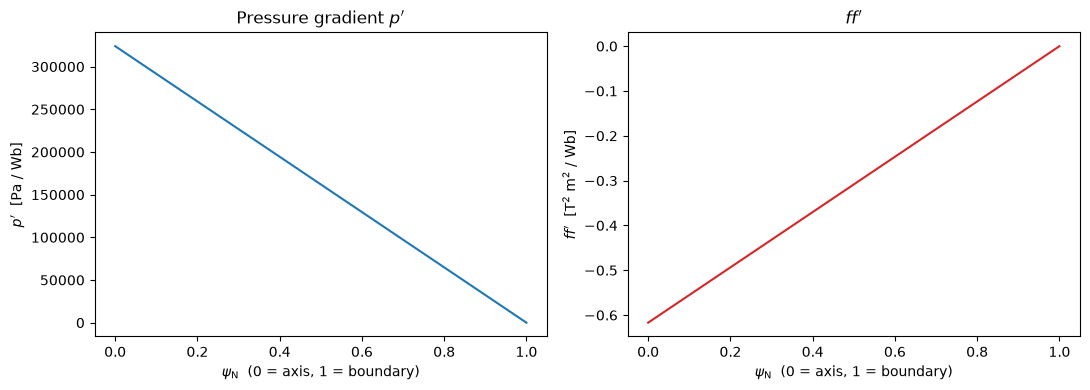

In [10]:
# --- Free-function derivatives p' and ff' vs normalised flux ---
# IMAS convention: derivatives with respect to the total poloidal flux [weber]
profile_psi_n = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)
profile_p_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.dpressure_dpsi)
profile_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)

fig, (ax_p_prime, ax_ff_prime) = plt.subplots(1, 2, figsize=(11, 4))

ax_p_prime.plot(profile_psi_n, profile_p_prime, color="tab:blue")
ax_p_prime.set_xlabel("$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
ax_p_prime.set_ylabel("$p'$  [Pa / Wb]")
ax_p_prime.set_title("Pressure gradient $p'$")

ax_ff_prime.plot(profile_psi_n, profile_ff_prime, color="tab:red")
ax_ff_prime.set_xlabel("$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
ax_ff_prime.set_ylabel("$ff'$  [T$^2$ m$^2$ / Wb]")
ax_ff_prime.set_title("$ff'$")

fig.tight_layout()
plt.show()

In [11]:
# --- Reconstruct the GF equilibrium with GSFit from the synthetic coils + magnetics ---
# Feed the fitted PF coils and the synthetic BP probes / flux loops into the GSFit inverse
# Grad-Shafranov solver. Every other sensor family (Rogowski, pressure, isoflux, ...) is created
# but left empty. Requires the get_coils cell (which also builds `wall`) and the synthetic-sensor cell above.
import time as time_py

import gsfit_rs
from gsfit_rs import Coils, Dialoop, Isoflux, IsofluxBoundary, Passives, Plasma, Pressure, RogowskiCoils, StationaryPoint, Tf, solve_grad_shafranov

# --- Initial guess: the GF plasma current and magnetic axis ---
# The fitted coils reproduce the field of the FULL plasma current, so the seed blob must carry a
# realistic current to form a confined region against them.
ip_gf = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.ip)
print(f"GF plasma current (seed): {ip_gf / 1.0e3:.1f} kA;  magnetic axis R = {mag_r:.3f} m, Z = {mag_z:.4f} m")

# --- Coils: one single-filament PF coil per fitted GF boundary node ---
# Rebuilt rather than reusing `gf_coils`, whose single time point cannot be interpolated onto the reconstruction times
coils = Coils()
for i_coil in range(n_coil):
    coils.add_pf_coil(
        name=gf_coil_names[i_coil],
        r=np.array([coil_r[i_coil]]),
        z=np.array([coil_z[i_coil]]),
        d_r=np.array([1.0e-3]),
        d_z=np.array([1.0e-3]),
        time=np.array([0.0, 1.0]),
        measured=np.array([coil_current[i_coil], coil_current[i_coil]]),
    )

# --- Toroidal field: the `tf` IDS holds f_vac = R0 * B_phi0, quoted at the reference radius R0 = r_geo ---
f_vac = r_geo * b_vacuum  # [tesla * metre]
tf = Tf()
tf.set_r0(r_geo)
tf.set_b_field_phi_vacuum_r(time=np.array([0.0, 1.0]), data=np.array([f_vac, f_vac]))

# --- Plasma: reconstruction grid, EFIT-polynomial p' / ff' source functions, and solver numerics ---
# GF p' and ff' are linear in psi_norm, so 2 polynomial degrees of freedom reproduce them exactly.
no_regularisation = np.zeros((1, 2))
p_prime_source_function = gsfit_rs.EfitPolynomial(2, no_regularisation)
ff_prime_source_function = gsfit_rs.EfitPolynomial(2, no_regularisation)

# GSFit grid: 0.03 m inside the GF grid, so the fitted coils (on the GF grid boundary) sit strictly OUTSIDE it, which avoids Greens
# self-term singularities. The wall is 0.10 m inside the coils, so it has several GSFit grid columns and rows outside it on every side.
d_grid_gsfit = 0.02  # [metre]
gs_r_min = gf.r_min + 0.03  # [metre]
gs_z_min = gf.z_min + 0.03  # [metre]
gs_n_r = math.floor((gf.r_max - 0.03 - gs_r_min) / d_grid_gsfit) + 1
gs_n_z = math.floor((gf.z_max - 0.03 - gs_z_min) / d_grid_gsfit) + 1
gs_r_max = gs_r_min + (gs_n_r - 1) * d_grid_gsfit  # [metre]
gs_z_max = gs_z_min + (gs_n_z - 1) * d_grid_gsfit  # [metre]
print(f"GSFit grid: R in [{gs_r_min:.4f}, {gs_r_max:.4f}] m, Z in [{gs_z_min:.4f}, {gs_z_max:.4f}] m, {gs_n_r}x{gs_n_z}")

plasma = Plasma(
    n_r=gs_n_r,
    n_z=gs_n_z,
    r_min=gs_r_min,
    r_max=gs_r_max,
    z_min=gs_z_min,
    z_max=gs_z_max,
    psi_norm=np.linspace(0.0, 1.0, 100),
    p_prime_source_function=p_prime_source_function,
    ff_prime_source_function=ff_prime_source_function,
    initial_guess_ip=ip_gf,  # [ampere]
    initial_guess_cur_r=mag_r,  # [metre]
    initial_guess_cur_z=mag_z,  # [metre]
    initial_guess_minor_radius=0.8 * a_minor,  # [metre]
    initial_guess_elongation=0.5 * (kappa + kappa_x),  # [dimensionless]
    n_iter_max=80,
    n_iter_min=0,
    grad_shafranov_deviation_tolerance=5.0e-6,
    nonlinear_solver_method="picard",
    picard_n_iter_no_vertical_feedback=1,
    picard_apply_anderson_mixing=False,
    picard_anderson_n_history=5,
    picard_anderson_mixing=1.0,
    newton_krylov_picard_handover=1.0e-2,
    newton_krylov_n_krylov_max=10,
    newton_krylov_krylov_tolerance=0.1,
    newton_krylov_finite_difference_step=1.0,
    newton_krylov_verbose=False,
    newton_picard_n_basis_max=10,
    newton_picard_contraction_threshold=0.5,
    newton_picard_finite_difference_step=1.0,
    newton_picard_verbose=False,
    times_to_reconstruct=np.array([0.0]),  # [second]; one equilibrium time-slice is allocated per time
)

# --- Sensor families the solver requires but that we leave empty for this test ---
passives = Passives()
rogowski_coils = RogowskiCoils()
pressure_sensors = Pressure()
isoflux = Isoflux()
isoflux_boundary = IsofluxBoundary()
stationary_point = StationaryPoint()
dialoop = Dialoop()

# --- Greens functions between every current source and every sensor ---
plasma.greens_with_coils(coils)
bp_probes.greens_with_coils(coils)
flux_loops.greens_with_coils(coils)
rogowski_coils.greens_with_coils(coils)
isoflux.greens_with_coils(coils)
isoflux_boundary.greens_with_coils(coils)
pressure_sensors.greens_with_coils(coils)
stationary_point.greens_with_coils(coils)

plasma.greens_with_passives(passives)
bp_probes.greens_with_passives(passives)
flux_loops.greens_with_passives(passives)
rogowski_coils.greens_with_passives(passives)
isoflux.greens_with_passives(passives)
isoflux_boundary.greens_with_passives(passives)
pressure_sensors.greens_with_passives(passives)
stationary_point.greens_with_passives(passives)

bp_probes.greens_with_plasma(plasma)
flux_loops.greens_with_plasma(plasma)
rogowski_coils.greens_with_plasma(plasma)
isoflux.greens_with_plasma(plasma)
isoflux_boundary.greens_with_plasma(plasma)
pressure_sensors.greens_with_plasma(plasma)
stationary_point.greens_with_plasma(plasma)

# --- Solve the inverse Grad-Shafranov problem (mutates plasma and the sensor objects) ---
# The reconstruction times and numerics are read from `plasma`, the toroidal field from `tf`, and the limiter from `wall`.
tic = time_py.time()
solve_grad_shafranov(
    plasma=plasma,
    wall=wall,
    tf=tf,
    coils=coils,
    passives=passives,
    bp_probes=bp_probes,
    flux_loops=flux_loops,
    rogowski_coils=rogowski_coils,
    isoflux=isoflux,
    isoflux_boundary=isoflux_boundary,
    pressure_sensors=pressure_sensors,
    stationary_point=stationary_point,
    dialoop=dialoop,
)
print(f"GSFit inverse solve finished in {time_py.time() - tic:.2f} s")

GF plasma current (seed): 484.4 kA;  magnetic axis R = 1.738 m, Z = -0.0027 m
GSFit grid: R in [1.0573, 2.2373] m, Z in [-1.0931, 0.9669] m, 60x104
solve_grad_shafranov starting
GSFit inverse solve finished in 1.47 s
solve_grad_shafranov: serial setup done; 224.04ms
solve_grad_shafranov: parallel time-slice solve done; 1041.99ms
time=   0.0ms;  solution_found=true;  gs_error=0.000000694919125842;  n_iter=8
equilibrium_post_processor: starting
solve_grad_shafranov: serial finish done; 198.85ms


GSFit convergence: converged
BP probe  fit RMS residual: 7.866e-06 T  (0.003% of span)
flux loop fit RMS residual: 1.758e-05 Wb (0.007% of span)
                         GF        GSFit   relative error
ip [A]                 4.8439e+05   4.8439e+05   +1.176e-06
magnetic axis R [m]        1.7377       1.7376   -2.741e-05
magnetic axis Z [m]    -0.0026613   -0.0026687   -2.804e-03
q_95                       6.1948        6.196   +1.928e-04
beta_pol                   2.1663       2.1667   +1.543e-04
li_3                       1.0054      0.99663   -8.746e-03
volume [m^3]                9.348       9.3498   +1.915e-04
energy_mhd [J]         3.9522e+05   3.9528e+05   +1.567e-04


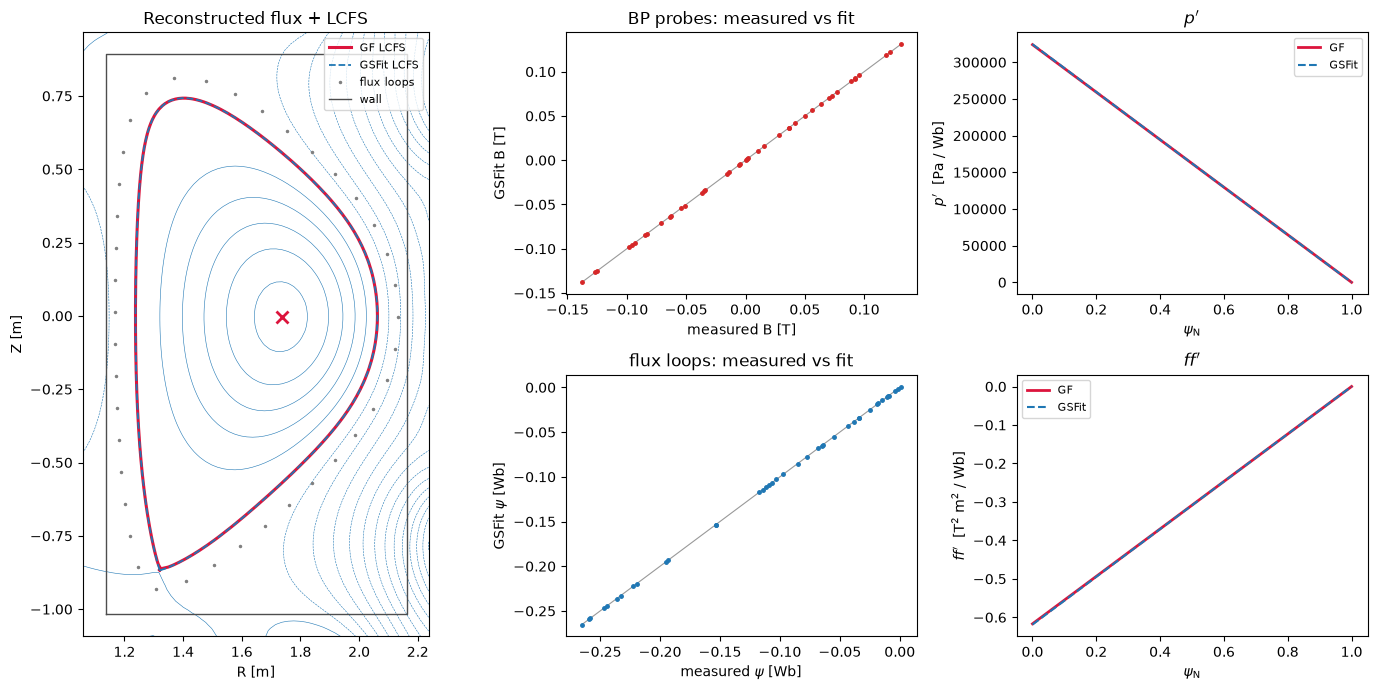

In [12]:
# --- Validate: GSFit reconstruction vs the GF free-boundary equilibrium ---
# The equilibrium IDS is a snapshot copy, so read it once after the solve
gsfit_equilibrium_ids = plasma.equilibrium_ids

gsfit_time = gsfit_equilibrium_ids.get(ep.time_slice[:].time)
i_time = int(np.argmin(np.abs(gsfit_time - 0.0)))
print(f"GSFit convergence: {gsfit_equilibrium_ids.get(ep.time_slice[i_time].convergence.result.name)}")

# `profiles_2d[0]` because GSFit solves on a single rectangular (R, Z) grid
gsfit_grid_r = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_2d[0].grid.dim1)
gsfit_grid_z = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_2d[0].grid.dim2)
gsfit_psi = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_2d[0].psi)
# The IDS stores each time-slice's boundary at its true length, so no trimming is needed
gsfit_boundary_r = gsfit_equilibrium_ids.get(ep.time_slice[i_time].boundary.outline.r)
gsfit_boundary_z = gsfit_equilibrium_ids.get(ep.time_slice[i_time].boundary.outline.z)

gf_boundary_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
gf_boundary_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)

# --- Sensor fit quality: measured (from GF) vs calculated (GSFit forward model) ---
bp_measured = np.array([bp_probes.get_array1([name, "b", "experimental", "value"])[i_time] for name in bp_probe_names])
bp_fit = np.array([bp_probes.get_array1([name, "b", "calculated", "value"])[i_time] for name in bp_probe_names])
fl_measured = np.array([flux_loops.get_array1([name, "psi", "experimental", "value"])[i_time] for name in flux_loop_names])
fl_fit = np.array([flux_loops.get_array1([name, "psi", "calculated", "value"])[i_time] for name in flux_loop_names])
bp_rms = np.sqrt(np.mean((bp_fit - bp_measured) ** 2))
fl_rms = np.sqrt(np.mean((fl_fit - fl_measured) ** 2))
print(f"BP probe  fit RMS residual: {bp_rms:.3e} T  ({100 * bp_rms / (bp_measured.max() - bp_measured.min()):.3f}% of span)")
print(f"flux loop fit RMS residual: {fl_rms:.3e} Wb ({100 * fl_rms / (fl_measured.max() - fl_measured.min()):.3f}% of span)")

# --- Global quantities: GSFit vs GF ---
print("                         GF        GSFit   relative error")
for quantity_name, quantity_path in [
    ("ip [A]", ep.time_slice[0].global_quantities.ip),
    ("magnetic axis R [m]", ep.time_slice[0].global_quantities.magnetic_axis.r),
    ("magnetic axis Z [m]", ep.time_slice[0].global_quantities.magnetic_axis.z),
    ("q_95", ep.time_slice[0].global_quantities.q_95),
    ("beta_pol", ep.time_slice[0].global_quantities.beta_pol),
    ("li_3", ep.time_slice[0].global_quantities.li_3),
    ("volume [m^3]", ep.time_slice[0].global_quantities.volume),
    ("energy_mhd [J]", ep.time_slice[0].global_quantities.energy_mhd),
]:
    gf_value = gf_equilibrium_ids.get(quantity_path)
    gsfit_value = gsfit_equilibrium_ids.get(quantity_path)
    print(f"{quantity_name:20s} {gf_value:12.5g} {gsfit_value:12.5g}   {(gsfit_value - gf_value) / abs(gf_value):+.3e}")

# --- Reconstructed vs GF profiles. Both IDSs follow the IMAS convention, derivatives with respect to the total flux [weber] ---
gf_psi_n = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)
gf_p_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.dpressure_dpsi)
gf_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)
gsfit_psi_n = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_1d.psi_norm)
gsfit_p_prime = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_1d.dpressure_dpsi)
gsfit_ff_prime = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_1d.f_df_dpsi)

fig = plt.figure(figsize=(14, 7))
grid_spec = fig.add_gridspec(2, 3, width_ratios=[1.2, 1.0, 1.0])
ax_eq = fig.add_subplot(grid_spec[:, 0])
ax_bp = fig.add_subplot(grid_spec[0, 1])
ax_fl = fig.add_subplot(grid_spec[1, 1])
ax_pp = fig.add_subplot(grid_spec[0, 2])
ax_ffp = fig.add_subplot(grid_spec[1, 2])

# Equilibrium overlay
ax_eq.contour(gsfit_grid_r, gsfit_grid_z, gsfit_psi, levels=25, colors="tab:blue", linewidths=0.4)
ax_eq.plot(gf_boundary_r, gf_boundary_z, color="crimson", lw=2.2, label="GF LCFS")
ax_eq.plot(gsfit_boundary_r, gsfit_boundary_z, color="tab:blue", lw=1.3, ls="--", label="GSFit LCFS")
ax_eq.plot(flux_loop_r, flux_loop_z, ".", color="0.5", ms=3, label="flux loops")
ax_eq.plot(limiter_r, limiter_z, color="0.3", lw=1.0, label="wall")
ax_eq.plot(mag_r, mag_z, "x", color="crimson", ms=8, mew=2)
ax_eq.set_aspect("equal")
ax_eq.set_xlabel("R [m]")
ax_eq.set_ylabel("Z [m]")
ax_eq.set_title("Reconstructed flux + LCFS")
ax_eq.legend(loc="upper right", fontsize=8)

# BP probe fit
bp_lims = [min(bp_measured.min(), bp_fit.min()), max(bp_measured.max(), bp_fit.max())]
ax_bp.plot(bp_lims, bp_lims, color="0.6", lw=0.8)
ax_bp.plot(bp_measured, bp_fit, ".", color="tab:red", ms=5)
ax_bp.set_xlabel("measured B [T]")
ax_bp.set_ylabel("GSFit B [T]")
ax_bp.set_title("BP probes: measured vs fit")

# Flux loop fit
fl_lims = [min(fl_measured.min(), fl_fit.min()), max(fl_measured.max(), fl_fit.max())]
ax_fl.plot(fl_lims, fl_lims, color="0.6", lw=0.8)
ax_fl.plot(fl_measured, fl_fit, ".", color="tab:blue", ms=5)
ax_fl.set_xlabel("measured $\\psi$ [Wb]")
ax_fl.set_ylabel("GSFit $\\psi$ [Wb]")
ax_fl.set_title("flux loops: measured vs fit")

# Profiles
ax_pp.plot(gf_psi_n, gf_p_prime, color="crimson", lw=2.0, label="GF")
ax_pp.plot(gsfit_psi_n, gsfit_p_prime, color="tab:blue", ls="--", label="GSFit")
ax_pp.set_xlabel("$\\psi_\\mathrm{N}$")
ax_pp.set_ylabel("$p'$  [Pa / Wb]")
ax_pp.set_title("$p'$")
ax_pp.legend(fontsize=8)

ax_ffp.plot(gf_psi_n, gf_ff_prime, color="crimson", lw=2.0, label="GF")
ax_ffp.plot(gsfit_psi_n, gsfit_ff_prime, color="tab:blue", ls="--", label="GSFit")
ax_ffp.set_xlabel("$\\psi_\\mathrm{N}$")
ax_ffp.set_ylabel("$ff'$  [T$^2$ m$^2$ / Wb]")
ax_ffp.set_title("$ff'$")
ax_ffp.legend(fontsize=8)

fig.tight_layout()
plt.show()